# Exploration


proposed methods:

1. K-nearest neighbor
2. Logistic regression
3. Discriminant analysis
    a. Linear Discriminant Analysis
    b. Quadratic Discriminant analysis
4. Tree-based methods:
    a. classification trees
    b. random forsest
    c. bagging
5. Boosting
6. Support Vector Machines

## Order of operations

### Explore data

1. Explore the data, plotting
2. Normalize the data, perform outlier detection and encode categorical values (one-hot or similar)
3. Perform Feature selection

### For selected methods

1. Implement the method, either via something like sklearn or write custom implementation
2. Tune the method to perform well
3. Evaluate performance using cross validation. We are aonly allowed to validate on training_data.csv, but we can test on songs_to_classify.

### Handin

1. Select best method and submit prediction as a string of zeros and ones
2. Handin zip file with what is needed to recreate and report

In [65]:
# Import modules
import numpy as np
import pandas as pd
import random

# We use searborn for prettier plots
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# To get typehints
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from numpy.typing import NDArray
from typing import * # bad practice but I dont care

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
# Apply the default theme
sns.set_theme()

In [2]:
# Load data
train = pd.read_csv("labs/lab_1_music_taste_prediction/data/training_data.csv")
test = pd.read_csv("labs/lab_1_music_taste_prediction/data/songs_to_classify.csv")
print(train.shape, test.shape)

(750, 14) (200, 13)


In [3]:
# Inspect data

sample = train.sample(5)
sample

,acousticness,danceability,duration,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,label
506,0.4350,0.658,242861,0.591,0.000082,2,0.123,-5.221,1,0.0647,126.829,4,0.483,0
357,0.0682,0.602,245053,0.796,0.120000,0,0.150,-3.657,0,0.1030,126.060,4,0.265,1
133,0.0141,0.697,228427,0.949,0.000000,0,0.748,-7.202,1,0.0353,132.379,4,0.904,0
250,0.7970,0.292,175667,0.771,0.196000,10,0.148,-3.726,0,0.0453,128.235,4,0.228,1
299,0.7460,0.486,247227,0.513,0.002130,0,0.113,-9.397,1,0.0349,129.131,4,0.394,1


## Exploring the data

## Basic cleaning / Checking

In [53]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      750 non-null    float64
 1   danceability      750 non-null    float64
 2   duration          750 non-null    int64  
 3   energy            750 non-null    float64
 4   instrumentalness  750 non-null    float64
 5   key               750 non-null    int64  
 6   liveness          750 non-null    float64
 7   loudness          750 non-null    float64
 8   mode              750 non-null    int64  
 9   speechiness       750 non-null    float64
 10  tempo             750 non-null    float64
 11  time_signature    750 non-null    int64  
 12  valence           750 non-null    float64
 13  label             750 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 82.2 KB


In [54]:
test.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   acousticness      200 non-null    float64
 1   danceability      200 non-null    float64
 2   duration          200 non-null    int64  
 3   energy            200 non-null    float64
 4   instrumentalness  200 non-null    float64
 5   key               200 non-null    int64  
 6   liveness          200 non-null    float64
 7   loudness          200 non-null    float64
 8   mode              200 non-null    int64  
 9   speechiness       200 non-null    float64
 10  tempo             200 non-null    float64
 11  time_signature    200 non-null    int64  
 12  valence           200 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 20.4 KB


### Single feature plots

Getting to know the features, not their relations

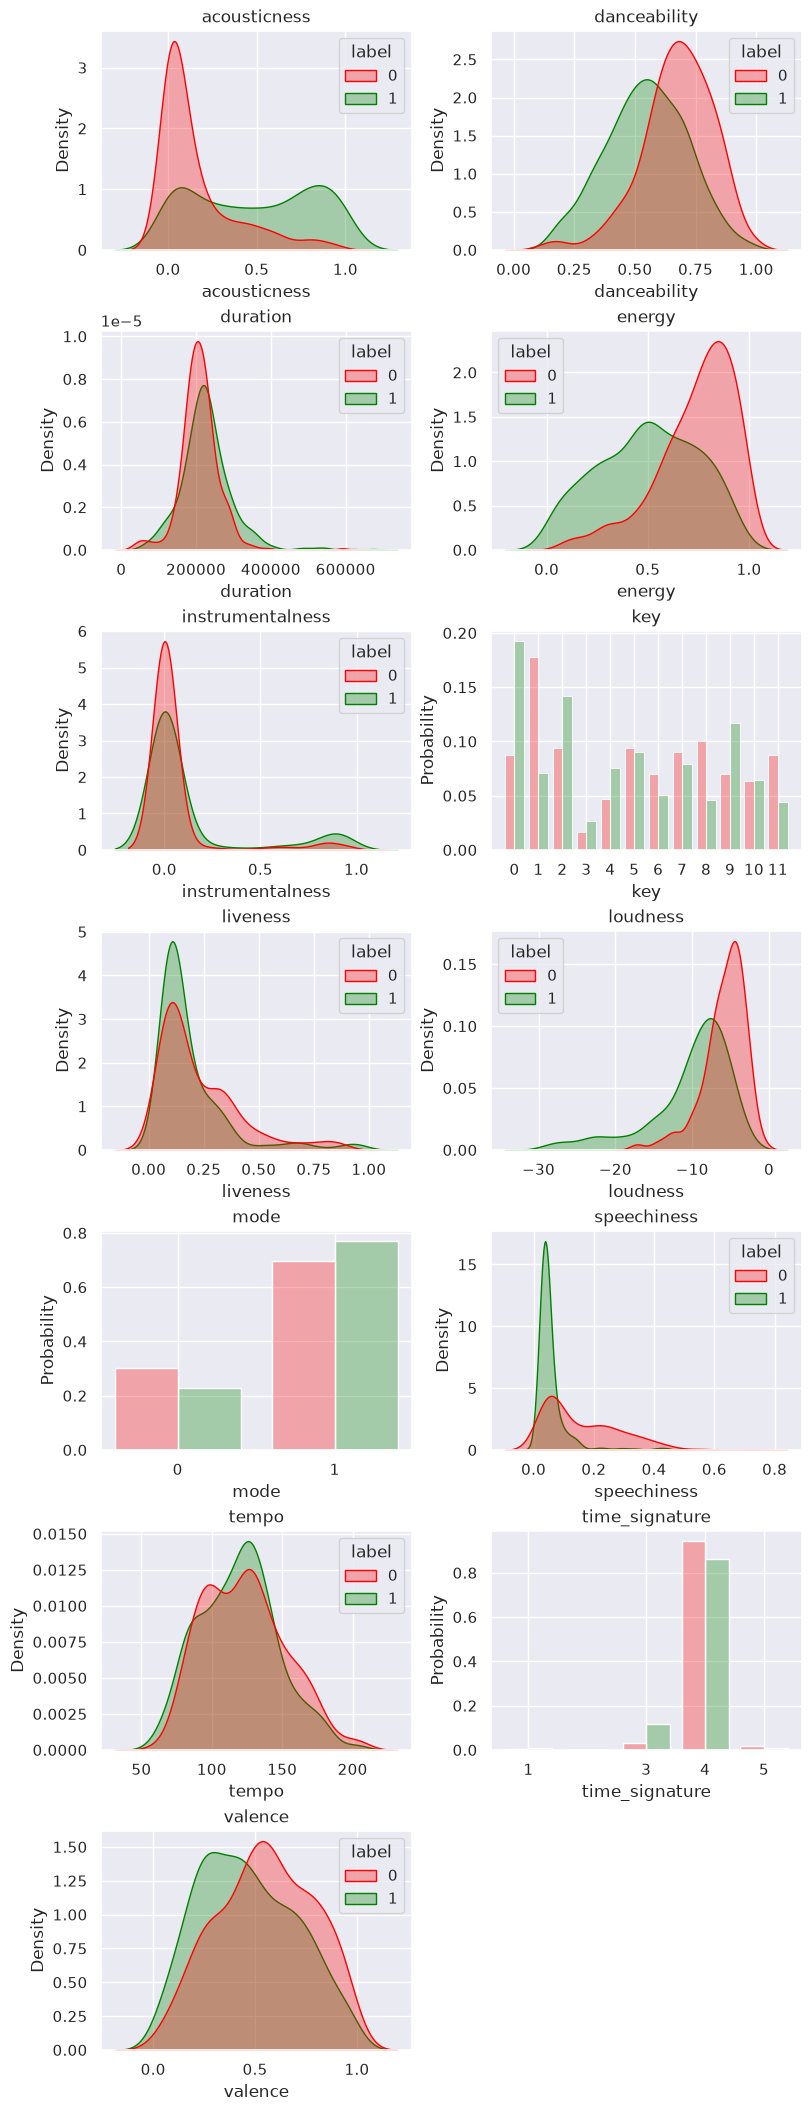

In [56]:
"""
label 0 -> red
label 1 -> blue

we have a bunch of different features

one start is to just plot the rows w.r.t. a single feature
"""

PALETTE = {0: "red", 1: "green"}
CMAP = LinearSegmentedColormap.from_list("label", ["red", "white", "blue"])

def single_feature_plots(df: pd.DataFrame, label_col_name: str = "label", n_fig_cols = 2, discrete_cols = ["key", "mode", "time_signature"]) -> None:

    """
    each plot: feature col and color from its label
    """

    feat_cols = [col for col in df.columns if col != label_col_name]
    n_feat_cols = len(feat_cols)

    n_fig_rows = int(np.ceil(n_feat_cols / n_fig_cols))
    fig, axs = plt.subplots(n_fig_rows, n_fig_cols, figsize=(4 * n_fig_cols, 3 * n_fig_rows), constrained_layout=True)
    fig: Figure
    axs: List[Axes]
    axs = np.atleast_1d(axs).ravel()


    for ax, col_name in zip(axs, feat_cols):

        # KDE works best with continous data, we use hist for discrete
        if col_name in discrete_cols:
            cats = np.sort(df[col_name].unique())
            sns.histplot(data=df, x=col_name, hue=label_col_name, palette=PALETTE,
                    discrete=True, stat="probability", common_norm=False,
                    multiple="dodge", shrink=0.8, legend=False, alpha=0.3, ax=ax)
            ax.set_xticks(cats)
        else:
            sns.kdeplot(data=df, x=col_name, hue=label_col_name, palette=PALETTE, alpha=0.3, common_norm=False, fill=True, ax=ax)

        ax.set_title(col_name)


    for ax in axs[n_feat_cols:]:
        ax.set_visible(False)

single_feature_plots(df=train)

### Feature engineering

#### Training a DecisionTreeClassifier to find out feature importances

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score



# Train a Decision Tree Classifier for each feature X
def get_feature_importances(train_features: pd.DataFrame, train_labels: pd.DataFrame) -> NDArray:
    # We don't need to scale the features for a tree-based classifier
    clf = DecisionTreeClassifier(max_depth=16, random_state=SEED)
    clf.fit(train_features, train_labels)
    return clf.feature_importances_


train_features = train.drop("label", axis=1)
train_labels = train["label"]
importances = get_feature_importances(train_features, train_labels)


In [67]:
importances

array([0.08984809, 0.04226261, 0.05817401, 0.04111863, 0.03536489,
       0.04282427, 0.01829373, 0.19993005, 0.        , 0.33965965,
       0.06669063, 0.01430096, 0.05153247])

#### Visualizing the effect of the importances

In [39]:
def plot_cont_cont(df: pd.DataFrame, ax:Axes, cont1: str, cont2:str, label_col_name: str = "label"):
    """Just a normal scatterplot with hue as the label"""
    sns.scatterplot(df, x=cont1, y=cont2, palette=PALETTE, alpha=0.3, hue=label_col_name, ax=ax)

def plot_disc_cont(df: pd.DataFrame, ax:Axes, disc: str, cont: str, label_col_name: str = "label"):
    """We can do a violin/box plot per label"""
    sns.violinplot(df, x=disc, y=cont, palette=PALETTE, alpha=0.3, hue=label_col_name, ax=ax)

def plot_disc_disc(df: pd.DataFrame, ax:Axes,disc1:str, disc2:str, label_col_name: str = "label") :
    """
    We can do some heatmap variant of labels with counts annotated
    
    Specifically, P(label=1 | disc1, disc2)
    """
    heatmap = pd.crosstab(train["key"], train["mode"], values=train["label"], aggfunc="mean") # 0 is dislike, 1 is like 
    sns.heatmap(data=heatmap, robust=True, annot=True, cmap=CMAP)